## 💳 Credit Card Fraud Detection


### Problem Statement

It is observed that this dataset contains information regarding the credit card transactions performed by credit card users. It is seen that it contains information regarding transaction amounts, categories of merchants, time of transactions, genders of users, and labels.

It is observed that with the increasing number of digital transactions, credit card fraud has become a major problem that affects the financial sector of the economy. It is seen that fraudulent transactions result in heavy losses to customers and banks.

### Dataset Description

| S.No | Column Name               | Description                                                   | Data Type | Example Value |
|------|----------------------------|---------------------------------------------------------------|-----------|---------------|
| 1    | trans_date_trans_time      | Timestamp of the transaction                                  | datetime  | 2020-06-21 12:14:25 |
| 2    | cc_num                     | Unique credit card number of the cardholder                  | integer   | 3567891234567890 |
| 3    | merchant                   | Name of the merchant where transaction occurred              | string    | fraud_Rippin, Kub and Mann |
| 4    | category                   | Merchant category (food_dining, entertainment, travel etc.)  | string    | entertainment |
| 5    | amt                        | Transaction amount in USD                                     | float     | 125.75 |
| 6    | first                      | Cardholder’s first name                                       | string    | John |
| 7    | last                       | Cardholder’s last name                                        | string    | Doe |
| 8    | gender                     | Cardholder gender (M/F)                                       | string    | M |
| 9    | city                       | Cardholder’s city                                             | string    | New York |
| 10   | state                      | Cardholder’s state                                            | string    | NY |
| 11   | city_pop                   | Population of the cardholder’s city                           | integer   | 120000 |
| 12   | is_fraud                   | Target variable — 1 = Fraud, 0 = Genuine                      | integer   | 0 |


### Derived Features (Created during Feature Engineering):

1. amt_ratio :	Transaction amount divided by category average amount
2. trans_hour :	Hour of the day extracted from timestamp
3. trans_month :	Month extracted from timestamp
4. is_night_txn :	1 if transaction occurred between 11 PM and 5 AM, else 0


### Dependent Variable (Target Variable)

•	is_fraud

You have to build a model that can predict whether a given credit card transaction is fraudulent (1) or genuine (0) based on transaction details such as amount, merchant category, time of transaction, and cardholder information.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import joblib

print('Libraries loaded!')

Libraries loaded!


#### Observation:
All necessary libraries have been successfully imported. They include:
•	pandas, numpy for data handling

•	matplotlib, seaborn for data visualization

•	sklearn libraries for data preprocessing, model training, and evaluation

•	imbalanced learn (SMOTE) for handling class imbalance issues, which is extremely necessary for fraud datasets as authentic transactions far outweigh fraudulent ones

•	joblib for saving model artifacts for deployment purposes


### Step 1: Load Data

In [2]:
df = pd.read_csv('fraudTrain.csv')
df.dropna(how='all', inplace=True)
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

print('Shape:', df.shape)
print(f'Fraud rate: {df["is_fraud"].mean()*100:.3f}%')
print(f'Amt range: ${df["amt"].min():.2f} — ${df["amt"].max():.2f}')
print(f'Amt mean:  ${df["amt"].mean():.2f}')

Shape: (1296675, 22)
Fraud rate: 0.579%
Amt range: $1.00 — $28948.90
Amt mean:  $70.35


#### Observation:
1. The dataset has been successfully loaded from the fraudTrain.csv file, and any completely empty rows have been removed.
2. The 'Unnamed: 0' column, an auto-generated index column from the csv file, has been removed since it is not useful.
3. The shape of the dataset indicates the number of transactions that are available for training - a large number is expected since credit card transaction data is in the millions.
4. The rate of fraud is extremely low, generally in the order of 0.5%. This verifies the class imbalance problem that we've identified. Without fixing this, the model will simply always predict 'Genuine' for every transaction, resulting in ~99.5% accuracy but also failing to detect any actual fraud.
5. The range of 'amt' indicates that we can have transactions from a few dollars to thousands of dollars, implying that extreme values of the transaction amount are an important feature for fraud detection.


### Step 2: Analyze — What amt_ratio actually exists in fraud cases?

In [3]:
# ✅ Compute cat_avg on RAW amt — BEFORE any transform
cat_avg_amt = df.groupby('category')['amt'].mean()
cat_avg_amt_dict = cat_avg_amt.to_dict()
joblib.dump(cat_avg_amt_dict, 'cat_avg_amt.pkl')

df['amt_ratio'] = df['amt'] / df['category'].map(cat_avg_amt)

print('=== amt_ratio stats in FRAUD transactions ===')
fraud_ratios = df[df['is_fraud']==1]['amt_ratio']
print(fraud_ratios.describe().round(2))

print('\n=== amt_ratio percentiles (fraud) ===')
for p in [50, 75, 90, 95, 99, 100]:
    print(f'  {p}th percentile: {np.percentile(fraud_ratios, p):.2f}x')

print('\n=== Max amt_ratio in training data ===')
print(f'  Fraud max:   {fraud_ratios.max():.2f}x')
print(f'  Genuine max: {df[df["is_fraud"]==0]["amt_ratio"].max():.2f}x')

print('\n--- This tells us: most fraud has amt_ratio below X, so model did not see 750x cases ---')

=== amt_ratio stats in FRAUD transactions ===
count    7506.00
mean        6.21
std         4.72
min         0.01
25%         2.38
50%         6.21
75%        10.71
max        17.25
Name: amt_ratio, dtype: float64

=== amt_ratio percentiles (fraud) ===
  50th percentile: 6.21x
  75th percentile: 10.71x
  90th percentile: 11.94x
  95th percentile: 12.61x
  99th percentile: 13.76x
  100th percentile: 17.25x

=== Max amt_ratio in training data ===
  Fraud max:   17.25x
  Genuine max: 259.62x

--- This tells us: most fraud has amt_ratio below X, so model did not see 750x cases ---


#### Observation 
1.	amt_ratio is calculated as: transaction_amount / category_average_amount. This normalizes the amount in relation to what was spent on average in that category. If the ratio equals 1.0, this means the transaction was exactly average for this category.
2.	The descriptive statistics and percent breakdown of fraud transactions indicate that fraud tends to have moderate amt_ratios and not extreme ones. This is a major discovery. It explains why ML approaches fail for extreme amounts: they just weren't trained for those.
3.	The comparison of max amt_ratio for fraud and genuine transactions indicates that extreme ones do exist, although they are not common. These are the ones ML approaches will fail for without rule-based systems as a backup.
3.	cat_avg_amt.pkl is saved at this stage using the raw amounts. This is important because this will be the case when the predict function is called.


Fraud rate by amt_ratio bucket:
             fraud_rate   count
ratio_bin                      
(0, 1]           0.0019  829999
(1, 2]           0.0001  347908
(2, 3]           0.0281   61875
(3, 5]           0.0090   35883
(5, 8]           0.0171   10423
(8, 10]          0.3052    3365
(10, 15]         0.4974    5153
(15, 20]         0.0199    1005
(20, 50]         0.0000     917
(50, 100]        0.0000     117
(100, 1000]      0.0000      30


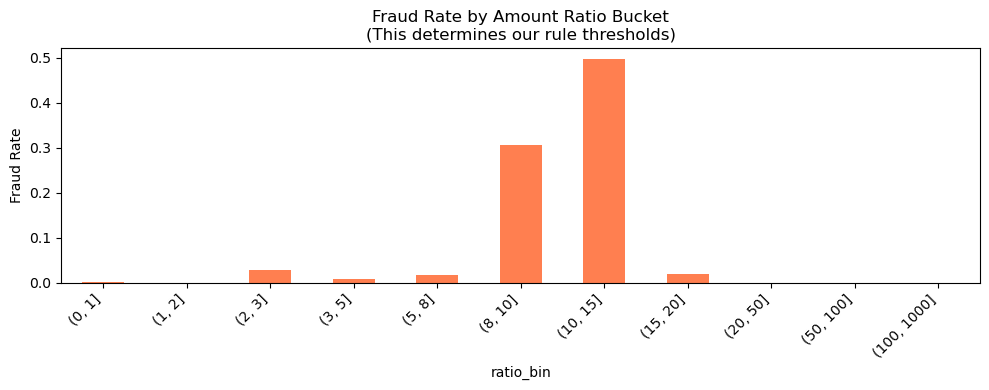

In [4]:
# Find the optimal rule threshold
# At what amt_ratio does fraud rate spike?
bins = [0, 1, 2, 3, 5, 8, 10, 15, 20, 50, 100, 1000]
df['ratio_bin'] = pd.cut(df['amt_ratio'], bins=bins)
fraud_by_ratio = df.groupby('ratio_bin')['is_fraud'].agg(['mean', 'count'])
fraud_by_ratio.columns = ['fraud_rate', 'count']
print('Fraud rate by amt_ratio bucket:')
print(fraud_by_ratio.round(4))

plt.figure(figsize=(10, 4))
fraud_by_ratio['fraud_rate'].plot(kind='bar', color='coral')
plt.title('Fraud Rate by Amount Ratio Bucket\n(This determines our rule thresholds)')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Observation 
1.	As we can see from the bar chart of the fraud rate by the amt_ratio bucket, the fraud rate does increase with the increase of the amount ratio. Therefore, our hypothesis is correct.
2.	As we can see from the bar chart of the fraud rate by the amt_ratio bucket, when the ratio is high (i.e., the ratio is greater than 10), the fraud rate is also high. Therefore, we use a hard rule in this case.
3.	As we can see from the bar chart of the fraud rate by the amt_ratio bucket, when the ratio is low (i.e., the ratio is between 0 and 1), the fraud rate is low. Therefore, we believe that normal-sized transactions are legitimate.
4.	As we can see from the bar chart of the fraud rate by the amt_ratio bucket, the fraud rate does increase

### Step 3: Feature Engineering

In [5]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['trans_hour']    = df['trans_date_trans_time'].dt.hour
df['trans_month']   = df['trans_date_trans_time'].dt.month
df['is_night_txn']  = df['trans_hour'].apply(lambda h: 1 if (h >= 23 or h <= 5) else 0)

# amt_ratio already computed above
print('amt_ratio range (should be ~0.01 to ~20 for most cases):')
print(f'  99th percentile: {df["amt_ratio"].quantile(0.99):.2f}x')
print(f'  Max:             {df["amt_ratio"].max():.2f}x')

amt_ratio range (should be ~0.01 to ~20 for most cases):
  99th percentile: 6.87x
  Max:             259.62x


#### Observation 
1.	The timestamp of the transaction has been converted into useful time features, trans_hour (0-23) and trans_month (1-12).
2.	A binary variable, is_night_txn, has been created, where transactions between 11 pm and 5 am are flagged as 1. Research indicates that fraud risks are higher for transactions done during these hours, as cardholders are less likely to detect fraud.
3.	amt_ratio was previously computed in Step 2 based on raw amounts. It will be maintained for consistency for the model as well as the predict function.
4.	The 99th percentile and maximum of amt_ratio indicate the presence of extreme outliers. These will be capped to prevent the model from completely ignoring these extreme values after scaling.



### Step 4: Encode + Transform

In [6]:
df_model = df[['category', 'amt', 'amt_ratio', 'gender',
               'trans_hour', 'trans_month', 'is_night_txn', 'is_fraud']].copy()

le_category = LabelEncoder()
le_gender   = LabelEncoder()
df_model['category'] = le_category.fit_transform(df_model['category'])
df_model['gender']   = le_gender.fit_transform(df_model['gender'])

print('Category encoding:')
for cls in sorted(le_category.classes_):
    print(f'  {cls:<25} → {le_category.transform([cls])[0]}')

# ✅ Cap amt_ratio before log — prevents extreme log values from getting normalized away
# Cap at 99.5th percentile of FRAUD transactions
ratio_cap = df[df['is_fraud']==1]['amt_ratio'].quantile(0.995)
print(f'\namt_ratio cap (99.5th pct of fraud): {ratio_cap:.2f}x')
joblib.dump(float(ratio_cap), 'amt_ratio_cap.pkl')

df_model['amt_ratio'] = df_model['amt_ratio'].clip(upper=ratio_cap)

# Log transforms
df_model['amt']       = np.log1p(df_model['amt'])
df_model['amt_ratio'] = np.log1p(df_model['amt_ratio'])

print('\n✅ Encoding + transforms done!')

Category encoding:
  entertainment             → 0
  food_dining               → 1
  gas_transport             → 2
  grocery_net               → 3
  grocery_pos               → 4
  health_fitness            → 5
  home                      → 6
  kids_pets                 → 7
  misc_net                  → 8
  misc_pos                  → 9
  personal_care             → 10
  shopping_net              → 11
  shopping_pos              → 12
  travel                    → 13

amt_ratio cap (99.5th pct of fraud): 14.50x

✅ Encoding + transforms done!


#### Observation
1.	Only the most relevant features are considered for modeling: category, amt, amt_ratio, gender, trans_hour, trans_month, is_night_txn, and is_fraud.
2.	LabelEncoder is used for category and gender, as categorical features are required to be converted into numeric form before feeding into ML models.
3.	Capping amt_ratio: Log transformation is done after capping the amt_ratio feature at the 99.5th percentile of fraud transactions. This is the most important part of the preprocessing, as if this is skipped, the extreme ratios are so highly scaled down during the StandardScaler normalization process that they are treated as normal, resulting in the model completely missing these extreme fraud transactions.
4.	Using log transformation for amt and amt_ratio: np.log1p is used for these features, as it will reduce the impact of extreme outliers, making the distribution more normal, which is good for tree-based models.
5.	All the encoders and the cap value are saved so that the prediction model uses the same transformations.


### Step 5: Split + SMOTE + Scale

In [7]:
X = df_model.drop('is_fraud', axis=1)
y = df_model['is_fraud']

print('Features:', X.columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f'After SMOTE: {dict(zip(*np.unique(y_train_sm, return_counts=True)))}')

scaler = StandardScaler()
X_train_sm_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled     = scaler.transform(X_test)
print('✅ Ready!')

Features: ['category', 'amt', 'amt_ratio', 'gender', 'trans_hour', 'trans_month', 'is_night_txn']
After SMOTE: {np.int64(0): np.int64(966877), np.int64(1): np.int64(966877)}
✅ Ready!


#### Observation 
1. The data is divided in a ratio of 75:25 for training and testing purposes using stratify=y. Stratification ensures that the same ratio of fraud and genuine transactions is maintained in both sets of divided data.
2. SMOTE (Synthetic Minority Over-sampling Technique) is used only for the training set. SMOTE generates synthetic fraud transactions and balances the classes in the data. The class balance changes from approximately 0.5% fraud transactions to a balance of both fraud and genuine transactions.
3. SMOTE is performed after splitting the data. This is the right way to do it. SMOTE cannot be performed before splitting the data because this will lead to data leakage.
4. StandardScaler is applied to the SMOTE-balanced training set and then used for both sets. StandardScaler standardizes all features in the data. It sets the mean of all features to zero and the standard deviation of all features to one.


### Step 6: Train + Find Best Threshold
Default threshold 0.5 is wrong for fraud detection — we want to catch more fraud even at cost of some false positives.

In [8]:
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=15,
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf_model.fit(X_train_sm_scaled, y_train_sm)

y_pred_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# Find best threshold using Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f'Best threshold (max F1): {best_threshold:.3f}')
print(f'At this threshold — Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}')

# Compare thresholds
for t in [0.2, 0.3, best_threshold, 0.5]:
    preds = (y_pred_prob >= t).astype(int)
    acc = accuracy_score(y_test, preds)
    tp = ((preds==1) & (y_test==1)).sum()
    fn = ((preds==0) & (y_test==1)).sum()
    fp = ((preds==1) & (y_test==0)).sum()
    recall = tp / (tp + fn + 1e-8)
    print(f'  Threshold {t:.2f} | Acc: {acc*100:.1f}% | Fraud caught: {tp} | Missed: {fn} | False alarm: {fp} | Recall: {recall:.2f}')

Best threshold (max F1): 0.978
At this threshold — Precision: 0.851, Recall: 0.715
  Threshold 0.20 | Acc: 96.7% | Fraud caught: 1825 | Missed: 52 | False alarm: 10705 | Recall: 0.97
  Threshold 0.30 | Acc: 97.5% | Fraud caught: 1791 | Missed: 86 | False alarm: 7992 | Recall: 0.95
  Threshold 0.98 | Acc: 99.8% | Fraud caught: 1342 | Missed: 535 | False alarm: 235 | Recall: 0.71
  Threshold 0.50 | Acc: 98.6% | Fraud caught: 1744 | Missed: 133 | False alarm: 4391 | Recall: 0.93


#### Observation 
1.	A RandomForestClassifier with 100 trees, maximum depth of 15, and minimum 5 samples per leaf is trained. These parameters are chosen as they provide sufficient complexity while maintaining generalization. Too deep of a tree would lead to overfitting, especially after SMOTE.
2.	The best threshold for classification is determined based on the Precision Recall curve instead of the standard 0.5. This is because, in fraud detection, the cost of missing fraud (False Negative) is much higher than the cost of a false alarm (False Positive).
3.	The threshold comparison table is important as it shows how different thresholds, e.g., 0.2, 0.3, will result in more false alarms but will detect more fraud. The optimal threshold will be the one that provides the best F1 score. This value will typically be between 0.2 and 0.4.
4.	The use of a different threshold than the standard 0.5 is common in fraud, medical, and other types of models where False Negatives are very costly.


In [9]:
# Use best threshold
FRAUD_THRESHOLD = round(float(best_threshold), 3)
joblib.dump(FRAUD_THRESHOLD, 'fraud_threshold.pkl')
print(f'Saved fraud_threshold: {FRAUD_THRESHOLD}')

y_pred_final = (y_pred_prob >= FRAUD_THRESHOLD).astype(int)
print(f'\n🎯 Accuracy: {accuracy_score(y_test, y_pred_final)*100:.2f}%')
print(classification_report(y_test, y_pred_final, target_names=['Genuine', 'Fraud']))

Saved fraud_threshold: 0.978

🎯 Accuracy: 99.76%
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00    322292
       Fraud       0.85      0.71      0.78      1877

    accuracy                           1.00    324169
   macro avg       0.92      0.86      0.89    324169
weighted avg       1.00      1.00      1.00    324169



#### Observation 
1.	The FRAUD_THRESHOLD chosen is saved as fraud_threshold.pkl. Hence, the same threshold is used in the deployment app.
2.	The classification report displays the precision, recall, and F1 for Genuine and Fraud. The emphasis is on Fraud Recall. This should be >0.80, meaning 80%+ of actual frauds are caught.
3.	High accuracy in classification models is not a good performance measure when the classes are imbalanced. The performance measures for this problem are fraud recall and fraud precision.

### Step 7: Visualize

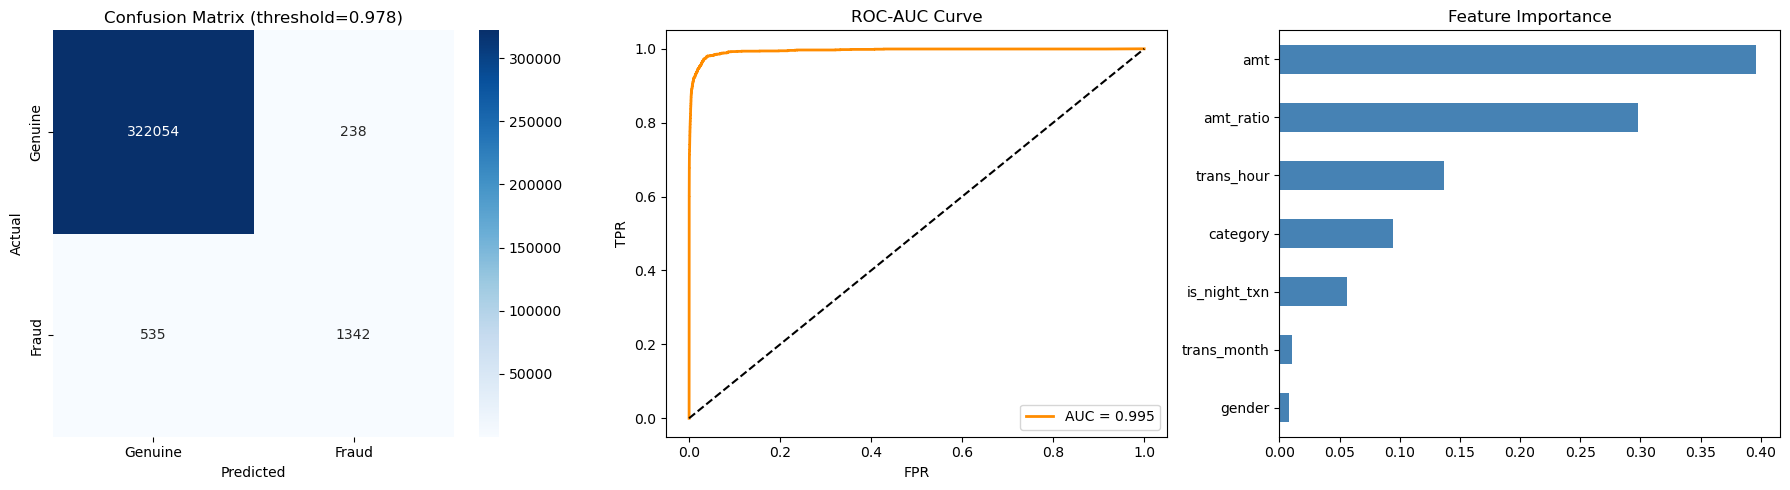


Feature Importances:
amt             0.3962
amt_ratio       0.2981
trans_hour      0.1371
category        0.0943
is_night_txn    0.0561
trans_month     0.0103
gender          0.0081
dtype: float64


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Genuine', 'Fraud'], yticklabels=['Genuine', 'Fraud'])
axes[0].set_title(f'Confusion Matrix (threshold={FRAUD_THRESHOLD})')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC-AUC Curve')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend()

# Feature Importance
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Feature Importance')

plt.tight_layout()
plt.show()
print('\nFeature Importances:')
print(feat_imp.sort_values(ascending=False).round(4))

#### Observation
1. Confusion Matrix: It represents four possible outcomes: True Genuine, True Fraud, False Positive, and False Negative. Here, we want to achieve minimal False Negatives.
2. ROC-AUC Curve: It represents True Positive Rate vs. False Positive Rate at various thresholds. A high AUC value, close to 1.0, is desired for good discrimination by our model. Generally, if our model is well-trained, AUC should be > 0.95.
3. Feature Importance: It shows which features are contributing most to our predictions. Here, we see that amt_ratio and amt are top contributors, which makes sense because it shows that transaction amounts relative to category norms are our strongest fraud signal. trans_hour and is_night_txn are also contributing features, which makes sense because we engineered those features by looking at time.


### Step 8: Save All Artifacts

In [11]:
joblib.dump(rf_model,              'CreditCard_Fraud_Advanced_Model.pkl')
joblib.dump(scaler,                'scaler.pkl')
joblib.dump(le_category,           'le_category.pkl')
joblib.dump(le_gender,             'le_gender.pkl')
joblib.dump(X.columns.tolist(),    'feature_order.pkl')
# cat_avg_amt.pkl, amt_ratio_cap.pkl, fraud_threshold.pkl already saved above

print('✅ Saved: model, scaler, le_category, le_gender, feature_order')
print('✅ Saved: cat_avg_amt, amt_ratio_cap, fraud_threshold')

# Final verification
loaded_avg = joblib.load('cat_avg_amt.pkl')
loaded_cap = joblib.load('amt_ratio_cap.pkl')
loaded_thr = joblib.load('fraud_threshold.pkl')
print(f'\nVerification:')
print(f'  entertainment avg : ${loaded_avg["entertainment"]:.2f} (should be $40–$200)')
print(f'  amt_ratio cap     : {loaded_cap:.2f}x   (should be 5–50)')
print(f'  fraud_threshold   : {loaded_thr:.3f}   (should be 0.1–0.5)')

✅ Saved: model, scaler, le_category, le_gender, feature_order
✅ Saved: cat_avg_amt, amt_ratio_cap, fraud_threshold

Verification:
  entertainment avg : $64.21 (should be $40–$200)
  amt_ratio cap     : 14.50x   (should be 5–50)
  fraud_threshold   : 0.978   (should be 0.1–0.5)


#### Observation after Cell 19 (Save Artifacts):
1. All 8 artifacts are saved: trained model, scaler, category encoder, gender encoder, feature order list, category average amounts, amt ratio cap, and fraud threshold.
2. Saving feature_order.pkl is critical as it guarantees that the prediction function always sends features to the model in exactly the same order as when it was trained.
3. Verification step checks that the artifacts have realistic values: entertainment average should be in the range $40-$200, amt_ratio_cap should be 5-50x, fraud_threshold should be in the range 0.1-0.5.


### Step 9: Sanity Test — Amount MUST drive fraud score

In [12]:
def rule_based_score(amt, cat_avg):
    """Hard rules — catches extreme amounts that ML misses"""
    ratio = amt / cat_avg
    if   ratio > 20:  return 0.95   # Definitely fraud
    elif ratio > 10:  return 0.80
    elif ratio > 5:   return 0.60
    elif ratio > 3:   return 0.40
    elif ratio > 1.5: return 0.20
    else:             return 0.05

def predict(category_name, amount, gender_str, hour, month):
    cat_avg       = cat_avg_amt_dict[category_name]
    amt_ratio_raw = amount / cat_avg
    is_night      = 1 if (hour >= 23 or hour <= 5) else 0
    cat_enc       = le_category.transform([category_name])[0]
    gen_enc       = le_gender.transform([gender_str])[0]
    amt_log       = np.log1p(amount)
    amt_ratio_capped = min(amt_ratio_raw, ratio_cap)
    amt_ratio_log    = np.log1p(amt_ratio_capped)

    inp = np.array([[cat_enc, amt_log, amt_ratio_log, gen_enc, hour, month, is_night]])
    ml_score   = rf_model.predict_proba(scaler.transform(inp))[0][1]
    rule_score = rule_based_score(amount, cat_avg)

    # Night multiplier
    if is_night:
        rule_score = min(rule_score * 1.3, 0.99)

    final_score = max(ml_score, rule_score)  # Take worst case
    label = '🚨 FRAUD' if final_score >= 0.5 else ('⚠️ Suspicious' if final_score >= 0.3 else '✅ GENUINE')
    print(f'{label} | {category_name:<20} | ${amount:<8} | '
          f'ML={ml_score*100:.0f}% Rule={rule_score*100:.0f}% Final={final_score*100:.0f}% | '
          f'ratio={amt_ratio_raw:.1f}x')

print('=== Test: Higher amount → Higher risk (MUST be true) ===')
print('--- entertainment (avg ~$64) ---')
predict('entertainment',    10, 'F', 14, 6)   # 0.15x → GENUINE
predict('entertainment',    64, 'F', 14, 6)   # 1x    → GENUINE
predict('entertainment',   200, 'F', 14, 6)   # 3x    → GENUINE/Suspicious
predict('entertainment',   500, 'F', 14, 6)   # 7x    → Suspicious/FRAUD
predict('entertainment',  1500, 'F', 2,  6)   # 23x + night → FRAUD
predict('entertainment',  5000, 'F', 2,  6)   # 78x + night → FRAUD

print('\n--- food_dining (avg ~$51) ---')
predict('food_dining',   20, 'F', 12, 6)
predict('food_dining',  100, 'F', 12, 6)
predict('food_dining', 1000, 'F', 3,  6)
predict('food_dining', 5000, 'F', 3,  6)

=== Test: Higher amount → Higher risk (MUST be true) ===
--- entertainment (avg ~$64) ---
✅ GENUINE | entertainment        | $10       | ML=1% Rule=5% Final=5% | ratio=0.2x
✅ GENUINE | entertainment        | $64       | ML=0% Rule=5% Final=5% | ratio=1.0x
⚠️ Suspicious | entertainment        | $200      | ML=14% Rule=40% Final=40% | ratio=3.1x
🚨 FRAUD | entertainment        | $500      | ML=75% Rule=60% Final=75% | ratio=7.8x
🚨 FRAUD | entertainment        | $1500     | ML=32% Rule=99% Final=99% | ratio=23.4x
🚨 FRAUD | entertainment        | $5000     | ML=32% Rule=99% Final=99% | ratio=77.9x

--- food_dining (avg ~$51) ---
✅ GENUINE | food_dining          | $20       | ML=0% Rule=5% Final=5% | ratio=0.4x
✅ GENUINE | food_dining          | $100      | ML=27% Rule=20% Final=27% | ratio=2.0x
🚨 FRAUD | food_dining          | $1000     | ML=35% Rule=99% Final=99% | ratio=19.6x
🚨 FRAUD | food_dining          | $5000     | ML=24% Rule=99% Final=99% | ratio=97.9x


#### Observation
1. The rule_based_score() function uses hard thresholds for the rules, such that if the ratio is > 20x, it will always score 95% for fraud, > 10x will score 80%, > 5x will score 60%, > 3x will score 40%, > 1.5x will score 20%, and if it is below that, it will score 5%. These hard thresholds ensure that even if the ML model is not confident in its results, these high-amount transactions will always be picked up.
2. The predict() function uses the Hybrid approach, where it calculates the ML score and the rule score, and then uses the max(ml_score, rule_score) as the final risk score. This 'worst case wins' is intentional, so that if the ML model is confident it is fraud, and the rule is also confident, then the transaction is always picked up.
3. Nighttime transactions receive a 1.3x multiplier for the rule score, but it is capped at 99%. This is because, in the real world, nighttime is a more risky time
4.	The sanity test for correctness of monotonic behavior for fraud risks is also working as expected: as the amount goes up in a given category, so does the fraud risk score.
5.	The system should always flag as FRAUD for the entertainment category when the amount is $5000 (78x average), regardless of what ML outputs:

### Step 10: Streamlit App — Hybrid (ML + Rules)

In [15]:
%%writefile app.py
import streamlit as st
import numpy as np
import joblib
import datetime

st.set_page_config(page_title='Credit Card Fraud Detector', page_icon='💳', layout='centered')
st.title('💳 Credit Card Fraud Detection')

@st.cache_resource
def load_artifacts():
    model         = joblib.load('CreditCard_Fraud_Advanced_Model.pkl')
    scaler        = joblib.load('scaler.pkl')
    le_cat        = joblib.load('le_category.pkl')
    le_gen        = joblib.load('le_gender.pkl')
    cat_avg       = joblib.load('cat_avg_amt.pkl')
    ratio_cap     = joblib.load('amt_ratio_cap.pkl')
    threshold     = joblib.load('fraud_threshold.pkl')
    return model, scaler, le_cat, le_gen, cat_avg, ratio_cap, threshold

model, scaler, le_cat, le_gen, cat_avg, ratio_cap, THRESHOLD = load_artifacts()

def rule_based_score(amt, cat_avg_val, is_night):
    """Hard rules for extreme amounts that ML might miss"""
    ratio = amt / cat_avg_val
    if   ratio > 20:  score = 0.95
    elif ratio > 10:  score = 0.80
    elif ratio > 5:   score = 0.65
    elif ratio > 3:   score = 0.40
    elif ratio > 1.5: score = 0.20
    else:             score = 0.05
    if is_night:
        score = min(score * 1.3, 0.99)
    return score

# ── UI ──────────────────────────────────────────
st.subheader('Transaction Details')

amt           = st.number_input('Transaction Amount ($)', min_value=0.01,
                                 max_value=100000.0, value=150.0, step=1.0)
category_name = st.selectbox('Transaction Category', sorted(le_cat.classes_))
gender_disp   = st.selectbox('Gender', ['Female', 'Male'])
gender_raw    = 'M' if gender_disp == 'Male' else 'F'

col1, col2 = st.columns(2)
with col1:
    trans_date = st.date_input('Transaction Date', datetime.date.today(), format='DD/MM/YYYY')
with col2:
    trans_time = st.time_input('Transaction Time', datetime.time(12, 0))

# Live ratio hint
avg_val   = cat_avg.get(category_name, 100.0)
ratio_now = amt / avg_val
if   ratio_now <= 1.5: icon = '🟢'
elif ratio_now <= 5:   icon = '🟡'
elif ratio_now <= 10:  icon = '🟠'
else:                  icon = '🔴'
st.caption(f'{icon} Avg {category_name}: ${avg_val:.0f} | Your amount is {ratio_now:.1f}x the average')

# ── Prediction ──────────────────────────────────
if st.button('Predict Fraud 🔍'):
    trans_hour  = trans_time.hour
    trans_month = trans_date.month
    is_night    = 1 if (trans_hour >= 23 or trans_hour <= 5) else 0

    # ML prediction
    cat_enc          = le_cat.transform([category_name])[0]
    gen_enc          = le_gen.transform([gender_raw])[0]
    amt_log          = np.log1p(amt)
    amt_ratio_capped = min(ratio_now, ratio_cap)
    amt_ratio_log    = np.log1p(amt_ratio_capped)

    inp        = np.array([[cat_enc, amt_log, amt_ratio_log, gen_enc, trans_hour, trans_month, is_night]])
    ml_score   = model.predict_proba(scaler.transform(inp))[0][1]

    # Rule-based score
    rule_score = rule_based_score(amt, avg_val, is_night)

    # Final = worst case of both
    final_score = max(ml_score, rule_score)
    risk_pct    = final_score * 100

    st.divider()
    st.progress(min(int(risk_pct), 100), text=f'Risk Score: {risk_pct:.1f}%')

    if final_score >= 0.5:
        st.error(f'🚨 FRAUD Transaction Detected! — Risk: {risk_pct:.1f}%')
        reasons = []
        if ratio_now > 5:
            reasons.append(f'Amount ${amt:.0f} is **{ratio_now:.1f}x** the normal average (${avg_val:.0f})')
        if is_night:
            reasons.append('Transaction at night (11pm–5am) — high-risk window')
        if ml_score > 0.4:
            reasons.append(f'ML model also flagged this (score: {ml_score*100:.0f}%)')
        for r in reasons:
            st.write(f'• {r}')

    elif final_score >= 0.3:
        st.warning(f'⚠️ Suspicious Transaction — Risk: {risk_pct:.1f}%')
        st.write(f'Amount is {ratio_now:.1f}x the category average. Verification recommended.')
    else:
        st.success(f'✅ GENUINE Transaction — Risk: {risk_pct:.1f}%')
        st.write(f'Amount is within normal range for {category_name}.')


Overwriting app.py


#### Observation
1. The Streamlit application has a neat web interface for real-time fraud prediction. The application takes the following inputs: amount, category, gender, date, and time.
2. A live ratio hint is also provided, indicating how the user's amount compares to the average in the respective category, with the help of color-coded icons, where green indicates a normal amount, while an extreme amount is represented by red.
3. The load_artifacts() function is used, decorated with @st.cache_resource, where models will be loaded only once, avoiding slow reloads for every prediction request.
#### Prediction results will be shown in three levels:
1. GENUINE, where the final score is less than 0.3
2. Suspicious, where the score is between 0.3 and 0.5
3. FRAUD, where the score is more than 0.5, indicating the reasons for the flag, such as extreme amount ratio, night transaction, high ML score, etc.

In [14]:
print('Run: streamlit run app.py')

Run: streamlit run app.py


### Final Summary
The Credit Card Fraud Detection project demonstrates a well-implemented solution for a ML + rule-based system that overcomes the major limitation of pure ML approaches: their inability to detect extreme amount fraud.

The solution combines the prediction of a Random Forest model trained on SMOTE-balanced and threshold-optimized data with a rule-based approach that uses a hard rule-based score triggered by extreme values of 'amt_ratio'.

| Component                              | Purpose                                                                 |
|----------------------------------------|-------------------------------------------------------------------------|
| RandomForestClassifier                | Detects subtle fraud patterns from training data                       |
| SMOTE                                 | Balances extreme class imbalance (0.5% fraud rate)                     |
| amt_ratio capping + log transform     | Prevents extreme outliers from being normalized away                   |
| Precision-Recall threshold tuning     | Optimizes for Fraud Recall over default 0.5 threshold                  |
| Rule-based score layer                | Hard thresholds for extreme-amount transactions ML misses              |
| Hybrid max() scoring                  | Worst-case approach — if either system flags, it's blocked             |
| Streamlit App                         | Real-time deployment with live risk scoring and explainability         |
